LEAD-LAG ANALYSIS

$\hat x_{IWM}(t+1) = \beta x_{SPY}(t) + \alpha + \epsilon(t)$ 

donde $x(t)$ es el log return.

Comparamos el error del modelo con la hipótesis nula:

$\hat x_{IWM} = \overline x_{IWM}$

--- Lead-Lag Decay Protocol ---
Null Hypothesis: Historical Mean (Campbell-Thompson)
Transaction Costs: 0 bps (Pure Signal)
Calculating Viscosity (Beta)...
Calculating Predictive Work Capacity (CSSED)...


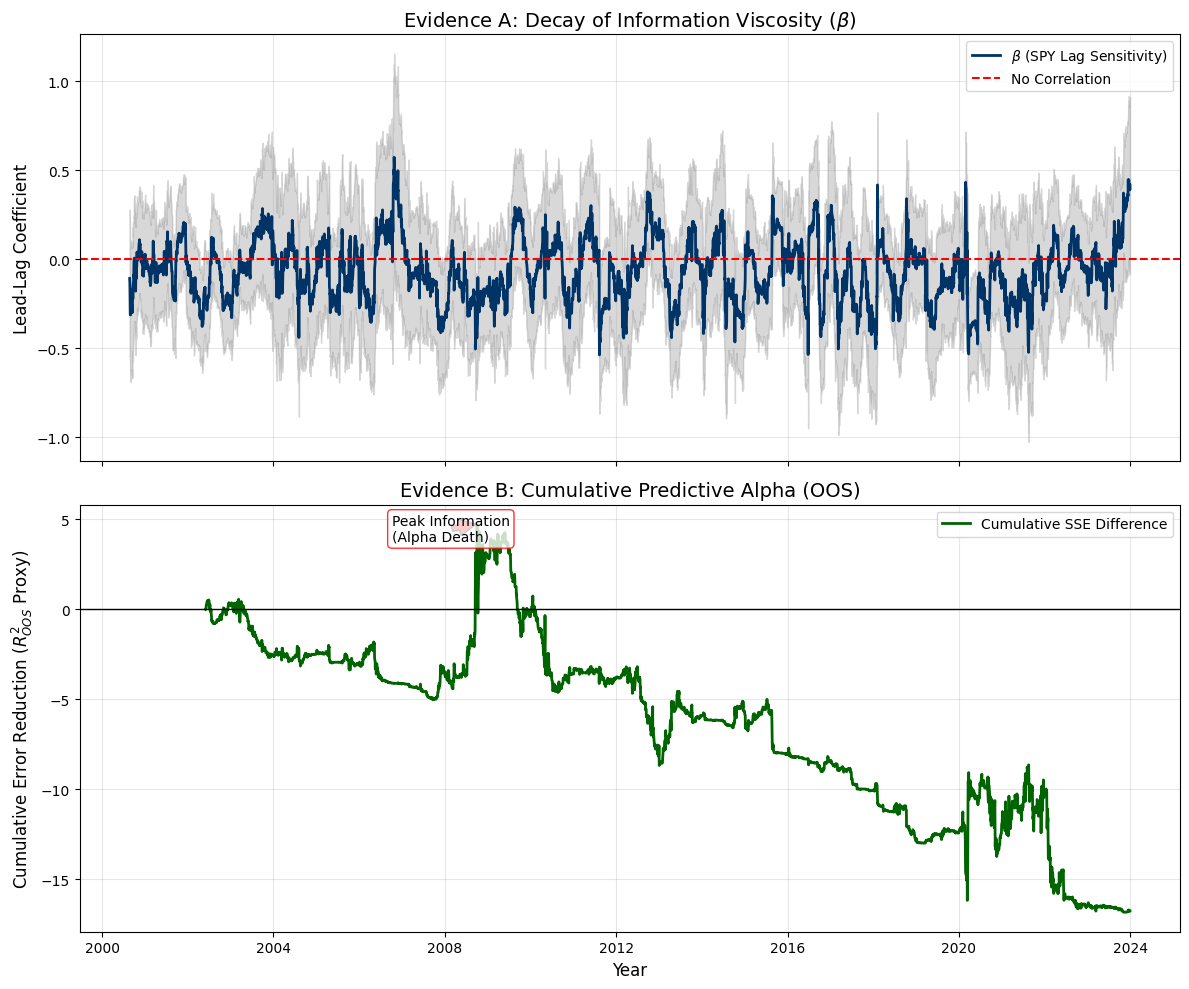

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. Experimental Setup
# ==========================================
tickers = ["SPY", "IWM"]
start_date = "2000-01-01"
end_date = "2024-01-01"
window_size = 60
min_training = 500 # Days to wait before starting OOS predictions

print(f"--- Lead-Lag Decay Protocol ---")
print(f"Null Hypothesis: Historical Mean (Campbell-Thompson)")
print(f"Transaction Costs: 0 bps (Pure Signal)")

# ==========================================
# 2. Data Ingestion & State Preparation
# ==========================================
data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=False)['Adj Close']

# Log-Returns (Stationary State)
returns = np.log(data / data.shift(1)).dropna()

# Feature Construction
# Y = IWM (Small Cap) at t
# X = SPY (Large Cap) at t-1
df = pd.DataFrame()
df['Y_Small'] = returns['IWM']
df['X_Large_Lag'] = returns['SPY'].shift(1)
df = df.dropna()

# ==========================================
# 3. Task A: Inference (The Rolling Beta)
# ==========================================
print("Calculating Viscosity (Beta)...")
exog_roll = sm.add_constant(df['X_Large_Lag'])
rolling = RollingOLS(df['Y_Small'], exog_roll, window=window_size)
rres = rolling.fit()
beta_series = rres.params['X_Large_Lag']
# Extract Uncertainty Bounds (95% Confidence Interval)
conf_int = rres.conf_int()

# FIX: Access the Variable Name first, then the Bound ID (0 = Lower, 1 = Upper)
lower_ci = conf_int['X_Large_Lag']['lower']
upper_ci = conf_int['X_Large_Lag']['upper']

# ==========================================
# 4. Task B: Prediction (OOS Performance)
# ==========================================
print("Calculating Predictive Work Capacity (CSSED)...")

pred_model = []
pred_null = []
actuals = []
variance = []
dates = []

# Convert to numpy for speed
X_vals = df['X_Large_Lag'].values.reshape(-1, 1)
Y_vals = df['Y_Small'].values

# Walk-Forward Loop with Rolling Window
# We use a fixed window (min_training days) to allow for regime adaptation
reg = LinearRegression()

for i in range(min_training, len(df)):
    # Information Set at time t-1 (Strict Causality)
    # Train on ROLLING window [i-min_training...i-1] for regime adaptation
    X_train = X_vals[i-min_training:i]
    Y_train = Y_vals[i-min_training:i]

    
    # 1. Fit Model (Lead-Lag)
    # Optimization: Re-fit every 20 days to speed up, predict daily
    if i % 1 == 0: 
        reg.fit(X_train, Y_train)
    
    r_hat_model = reg.predict(X_vals[i].reshape(1, -1))[0]
    # 2. Null Prediction (Historical Mean)
    r_hat_null = np.mean(Y_train)
    
    # 3. Store Results
    pred_model.append(r_hat_model)
    pred_null.append(r_hat_null)
    actuals.append(Y_vals[i])
    dates.append(df.index[i])

#Calculate Local Variance for Error Normalization
# Using a rolling window to estimate variance at each point in time
returns_series = pd.Series(Y_vals, index=df.index)
rolling_var = returns_series.rolling(window=window_size).var().dropna()
# Align variance with prediction dates
variance = rolling_var.loc[dates].values
# ==========================================
# 5. Quantification (Error Analysis)
# ==========================================

actuals = np.array(actuals)
pred_model = np.array(pred_model)
pred_null = np.array(pred_null)
variance = np.array(variance)

# Squared Errors
sq_err_model = (actuals - pred_model)**2/variance  # Variance-Adjusted Error
sq_err_null = (actuals - pred_null)**2/variance

# Cumulative Squared Error Difference (CSSED)
# A positive slope means the Model is beating the Null
cssed = np.cumsum(sq_err_null - sq_err_model)

# ==========================================
# 6. Visualization
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: The Physics (Viscosity Decay)
ax1.plot(beta_series.index, beta_series, color='#003366', linewidth=2, label=r'$\beta$ (SPY Lag Sensitivity)')
ax1.fill_between(beta_series.index, lower_ci, upper_ci, color='gray', alpha=0.3)
ax1.axhline(0, color='red', linestyle='--', label='No Correlation')
ax1.set_title(r'Evidence A: Decay of Information Viscosity ($\beta$)', fontsize=14)
ax1.set_ylabel(r'Lead-Lag Coefficient', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: The Engineering (Predictive Power)
ax2.plot(dates, cssed, color='darkgreen', linewidth=2, label='Cumulative SSE Difference')
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.set_title(r'Evidence B: Cumulative Predictive Alpha (OOS)', fontsize=14)
ax2.set_ylabel(r'Cumulative Error Reduction ($R^2_{OOS}$ Proxy)', fontsize=12)
ax2.set_xlabel('Year', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Annotation of the "Phase Transition"
# Automatically find the peak of the CSSED curve
peak_idx = np.argmax(cssed)
peak_date = dates[peak_idx]
ax2.annotate('Peak Information\n(Alpha Death)', xy=(peak_date, cssed[peak_idx]), 
             xytext=(dates[peak_idx-500], cssed[peak_idx]*0.8),
             arrowprops=dict(facecolor='red', shrink=0.05),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8))

plt.tight_layout()
plt.show()